# Fix : encodage de `set_serie`

Problème : `pd.Categorical(df["set_serie"]).codes` introduit une hiérarchie ordinale entre les séries (Base=0 < Neo=1 < etc.) alors qu'il n'y en a pas — le modèle peut croire que Sword & Shield "vaut plus" que Base juste parce que son code est plus grand.

Solution : one-hot encoding → chaque série devient une colonne binaire indépendante.  
Ce notebook explore d'abord l'impact de chaque série sur le prix avant de décider si on l'intègre.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

## Chargement et filtre

In [2]:
df = pd.read_csv("../data/raw/cartes_pokemon.csv")
print("shape brut:", df.shape)

# on garde uniquement les cartes avec un prix
df = df[df["prix_market"] > 0].copy()
print(f"{len(df)} cartes avec un prix")
df.head(3)

shape brut: (20237, 62)
18683 cartes avec un prix


,id,nom,supertype,rarity,set_name,set_serie,set_annee,set_total_cartes,set_printed_total,numero,...,prix_market,prix_mid,prix_low,prix_high,prix_cm_avg1,prix_cm_avg7,prix_cm_avg30,prix_cm_trend,prix_cm_low,prix_cm_reverse_trend
0,hgss4-1,Aggron,Pokémon,Rare Holo,HS—Triumphant,HeartGold & SoulSilver,2010,103,102,1,...,7.75,9.99,5.17,80.34,1.68,2.34,2.78,1.34,0.70,2.66
1,xy5-1,Weedle,Pokémon,Common,Primal Clash,XY,2015,164,160,1,...,0.12,0.20,0.01,19.99,0.15,0.11,0.11,0.12,0.02,0.80
2,pl1-1,Ampharos,Pokémon,Rare Holo,Platinum,Platinum,2009,133,127,1,...,29.34,30.53,16.93,389.50,3.00,4.75,4.40,4.43,0.99,4.01


## One-hot encoding de `set_serie`

In [3]:
# one-hot encoding — chaque série = une colonne binaire sans hiérarchie
dummies_serie = pd.get_dummies(df["set_serie"], prefix="serie")
df = pd.concat([df, dummies_serie], axis=1)

cols_serie = [c for c in df.columns if c.startswith("serie_")]
print(f"{len(cols_serie)} colonnes créées :")
print(cols_serie)

15 colonnes créées :
['serie_Base', 'serie_Black & White', 'serie_Diamond & Pearl', 'serie_E-Card', 'serie_EX', 'serie_HeartGold & SoulSilver', 'serie_Mega Evolution', 'serie_NP', 'serie_Other', 'serie_POP', 'serie_Platinum', 'serie_Scarlet & Violet', 'serie_Sun & Moon', 'serie_Sword & Shield', 'serie_XY']


## Prix moyen par série

In [4]:
# prix médian par série (médiane plus robuste aux cartes ultra-rares qui tirent la moyenne vers le haut)
prix_par_serie = (
    df.groupby("set_serie")["prix_market"]
    .agg(mediane="median", moyenne="mean", nb_cartes="count")
    .sort_values("mediane", ascending=False)
)
print(prix_par_serie.to_string())

                        mediane    moyenne  nb_cartes
set_serie                                            
NP                       39.990  81.892000         35
E-Card                   14.560  63.177960        505
POP                      10.260  40.098366        153
Other                     4.425  34.659145        234
Base                      2.590  27.024681        282
EX                        1.900  43.861660       1711
HeartGold & SoulSilver    1.485  19.571723        534
Platinum                  1.220  16.332766        517
Diamond & Pearl           1.020  12.162139        893
Black & White             0.690  18.921418       1432
Sun & Moon                0.470  14.373236       2908
XY                        0.450  13.003396       1902
Sword & Shield            0.290   7.576371       3662
Scarlet & Violet          0.180   8.235571       3597
Mega Evolution            0.150  10.008208        318


## Graphique : prix médian par série

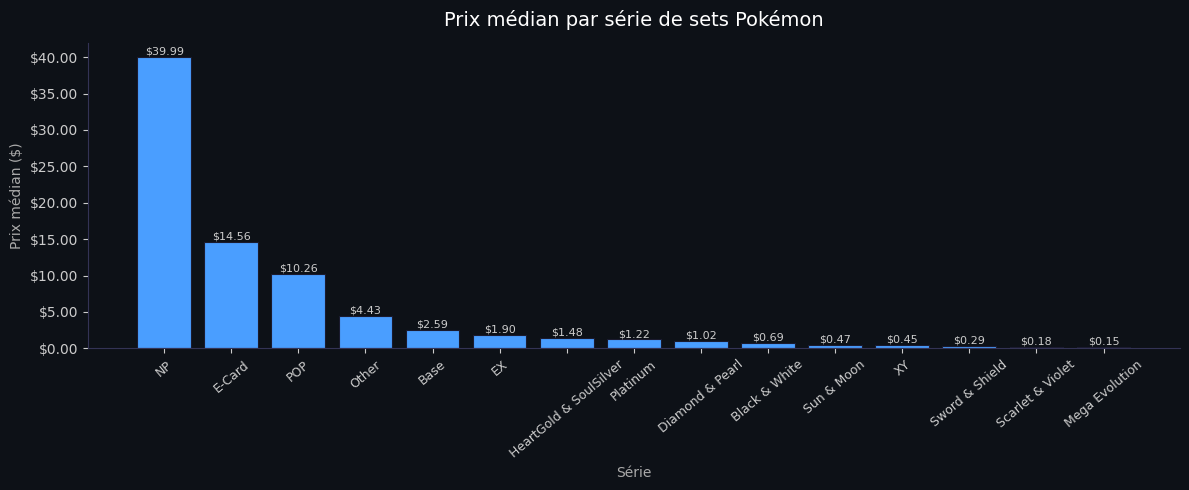

graphique sauvegardé dans data/processed/prix_par_serie.png


In [5]:
fig, ax = plt.subplots(figsize=(12, 5))

series_names = prix_par_serie.index.tolist()
medianes = prix_par_serie["mediane"].values

bars = ax.bar(series_names, medianes, color="#4A9EFF", edgecolor="#1A1A2E", linewidth=0.8)

# annoter chaque barre avec la valeur
for bar, val in zip(bars, medianes):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 0.05,
        f"${val:.2f}",
        ha="center", va="bottom", fontsize=8, color="#CCCCCC"
    )

ax.set_title("Prix médian par série de sets Pokémon", fontsize=14, pad=12, color="white")
ax.set_xlabel("Série", color="#AAAAAA")
ax.set_ylabel("Prix médian ($)", color="#AAAAAA")
ax.set_facecolor("#0D1117")
fig.patch.set_facecolor("#0D1117")
ax.tick_params(axis="x", rotation=40, labelsize=9, colors="#CCCCCC")
ax.tick_params(axis="y", colors="#CCCCCC")
ax.spines[["top", "right"]].set_visible(False)
ax.spines[["left", "bottom"]].set_color("#333355")
ax.yaxis.set_major_formatter(mticker.FormatStrFormatter("$%.2f"))

plt.tight_layout()
plt.savefig("../data/processed/prix_par_serie.png", dpi=150, bbox_inches="tight")
plt.show()
print("graphique sauvegardé dans data/processed/prix_par_serie.png")

## Conclusion

Le graphique montre clairement que certaines séries font monter le prix : les sets **vintage** (Base, Neo, E-Card, Gym) ont des médianes bien plus élevées que les sets récents (Sword & Shield, Sun & Moon).

L'encodage ordinal `pd.Categorical` ne capturait pas ça correctement — il mettait Base=0 (le moins cher en théorie) alors que c'est en réalité parmi les plus chers.  
Avec le one-hot encoding, le modèle peut apprendre le vrai signal de chaque série indépendamment.